# Vision Transformers

An image is a grip of patches. A sentence is a grid of tokens. The same transformer eats both.

## Problem definition

Slice an image into fixed-size patches, linearly project each patch into an embedding, feed the sequence to a vanilla transformer encoder.

## Basic Concetp

Images --> Patches --> Tokens --> Transformer

### Step1 patchify

Splie a `H x W x C` image into an `N x (P * P * C)` sequence of flat patches

### Step2 linear embedding

`nn.Conv2d(C, d_model, kernel_size=P, stride=P)`

### Step3 prepend `[CLS]` token, add positional embeddings

* Prepare a learnable `[CLS]` token. It's final hidden state is the image representation used for classification.
* Add learnable positional embeddings
* In 2024, RoPE extended to 2D for position

### Step4 Standard transformer encoder

Stack L blocks of `LayerNorm --> Self-Attention --> + --> LayerNorm --> MLP --> +`。 Indentical to BERT, No vision specific layers.

### Step5 head

For classification: take `[CLS]` hidden state --> linear --> softmax. For DINOv2 or SAM discard `[CLS]`, use the patch embeddings directly.

### Variant that matters

|Model|Year|Change|
|---|---|---|
|Vit|2020|Fixed patch size, full global attention|
|DeiT|2021|Distillation|
|Swin|2021|Hierarchical with shifted windows, Fixed sub-quadratic cost|
|DINOv2|2023|Self-supervised|
|Vit-22B|2023|22B params; scaling laws apply|
|SigLIP|2023|ViT + language pair, sigmoid contrastive loss|
|SAM3|2025|Segment anything, Vit-Large + promptable mask decoder|

### Training

Vit needs a lot of data to match CNNs because it has none of the CNN inductive biases (translation invariance, locality). Without >100M labeled imanges or strong self-supervised pretraining, CNNs still win at matched compute. 

DeiT fixed this in 2021 with distillation tricks.
DINOv2 fixed it permanently in 2023 with self-supervision

# Build your Own

===========================Image============================


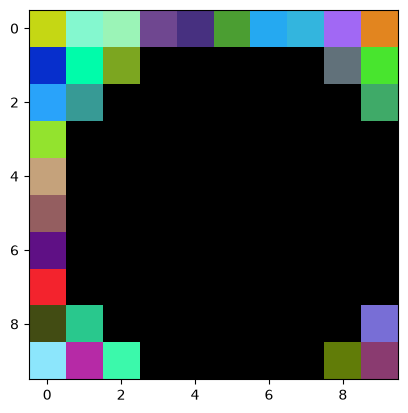

==========================Patchify==========================


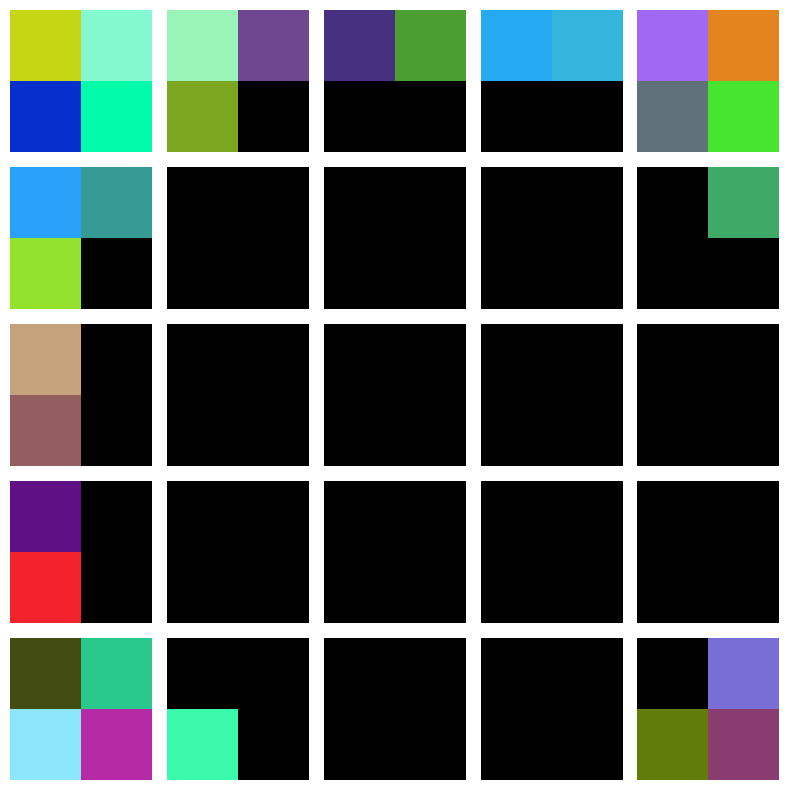

In [23]:
import math
import random

import sys
from pathlib import Path

sys.path.append(str(Path("../../00_Common").resolve()))
from user_tools import SectionPrinter


def make_image(H, W, C=3, seed=0):
    rng = random.Random(seed)
    return [
        [
            [rng.randint(0, 255) if (h - H/2)**2 + (w - W/2)**2 >= (H/2)**2 else 0 for _ in range(C)]
            for w in range(W)
        ]
        for h in range(H)
    ]

image = make_image(H=10, W=10, C=3, seed=0)

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

with SectionPrinter("Image"):
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.show()

def patchify(image, patch_size):
    H = len(image)
    W = len(image[0])
    C = len(image[0][0])

    assert H % patch_size == 0 and W % patch_size == 0

    patches = []
    grid = []
    for row_idx, i in enumerate(range(0, H, patch_size)):
        grid_row = []
        for col_idx, j in enumerate(range(0, W, patch_size)):
            patch = []
            for di in range(patch_size):
                for dj in range(patch_size):
                    patch.extend(image[i + di][j + dj])
            patches.append(patch)
            grid_row.append((row_idx, col_idx))
        grid.append(grid_row)

    return patches, (H // patch_size, W // patch_size), C

with SectionPrinter("Patchify"):
    patch_size = 2
    patches, grid_shape, C = patchify(image, patch_size=patch_size)

    fig, axes = plt.subplots(grid_shape[0], grid_shape[1], figsize=(8, 8))
    axes = np.atleast_1d(axes).ravel()  # subplots returns 2D array; flatten to real Axes
    for ax, patch in zip(axes, patches):
        patch_img = np.array(patch, dtype=np.uint8).reshape(patch_size, patch_size, C)
        ax.imshow(patch_img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()



In [24]:
def linear_project(patches, d_model, rng=None):
    if rng is None:
        rng = random.Random()

    in_dim = len(patches[0])
    scale = math.sqrt(2.0 / (in_dim + d_model))

    W = [
        [rng.gauss(0.0, scale) for _ in range(d_model)]
        for _ in range(in_dim)
    ]    

    out = []
    for patch in patches:
        row = [0.0] * d_model
        for i, x in enumerate(patch):
            if x == 0.0:
                continue
            for j in range(d_model):
                row[j] += x * W[i][j]
        out.append(row)
    
    return out, W

with SectionPrinter("Linear Projection"):
    patches, W = linear_project(patches, d_model=4)
    for i, patch in enumerate(patches):
        print(f"Patch {i}: {patch}")




=====================Linear Projection======================
Patch 0: [-61.578038716959014, -29.722111393014135, -308.22343970957877, 37.04739745229775]
Patch 1: [40.54666252697761, 221.57104521637564, -148.85155253332644, 4.753212809225618]
Patch 2: [18.822936198570318, 0.16994305624928163, -71.94590719032266, 31.34871193073745]
Patch 3: [43.81485175638905, 37.38485354438151, -167.4919853255249, -114.57893680824948]
Patch 4: [-90.11636444122635, 156.51731309784225, -352.4630684719406, 207.68973595580167]
Patch 5: [72.56535943932305, 205.73966863834792, -171.04036506355993, -49.69192335439424]
Patch 6: [0.0, 0.0, 0.0, 0.0]
Patch 7: [0.0, 0.0, 0.0, 0.0]
Patch 8: [0.0, 0.0, 0.0, 0.0]
Patch 9: [50.32704696236917, -56.59250179658531, -82.55391408872222, -20.588609550724854]
Patch 10: [-29.491350133692364, 155.93453116483528, 10.069423984403645, 15.911624672161082]
Patch 11: [0.0, 0.0, 0.0, 0.0]
Patch 12: [0.0, 0.0, 0.0, 0.0]
Patch 13: [0.0, 0.0, 0.0, 0.0]
Patch 14: [0.0, 0.0, 0.0, 0.0]
Pat

In [25]:
def cls_and_pos(tokens, grid_h, grid_w, rng=None):
    if rng is None:
        rng = random.Random()

    d_model = len(tokens[0])
    cls = [rng.gauss(0, 0.02) for _ in range(d_model)]
    pe = pos_2d(grid_h, grid_w, d_model)
    out = [list(cls)]
    idx = 0
    for i in range(grid_h):
        for j in range(grid_w):
            t = [tokens[idx][k] + pe[i][j][k] for k in range(d_model)]
            out.append(t)
            idx += 1
    return out

def pos_2d(grid_h, grid_w, d_model):
    assert d_model % 4 == 0
    half = d_model // 2
    pe = [
        [
            [0.0] * d_model
            for _ in range(grid_w)
        ]
        for _ in range(grid_h)
    ]

    for i in range(grid_h):
        for j in range(grid_w):
            for k in range(half // 2):
                theta_row = i / (10000 ** (2 * k / half))
                pe[i][j][2 * k] = math.sin(theta_row)
                pe[i][j][2 * k + 1] = math.cos(theta_row)
            for k in range(half // 2):
                theta_col = j / (10000 ** (2 * k / half))
                pe[i][j][half + 2 * k] = math.sin(theta_col)
                pe[i][j][half + 2 * k + 1] = math.cos(theta_col)
    return pe

with SectionPrinter("Positional Encoding"):
    patches, grid_shape, C = patchify(image, patch_size=2)
    tokens = linear_project(patches, d_model=4)[0]
    tokens = cls_and_pos(tokens, grid_h=grid_shape[0], grid_w=grid_shape[1])
    for i, token in enumerate(tokens):
        print(f"Token {i}: {token}")






====================Positional Encoding=====================
Token 0: [-0.024360403734639574, 0.003430829010426924, 0.01773225658886701, -0.002115236006934755]
Token 1: [96.3595999386211, 404.4220624815829, -165.1575490885776, 33.61154940289798]
Token 2: [109.42939143735447, 120.66894776976399, 50.63822375658666, -182.37690730716324]
Token 3: [36.52257258480303, -5.573680978818583, 18.262565998783636, -94.65804233849477]
Token 4: [-19.10731827698727, -72.57399958016845, -6.859085234311498, -184.68491408238862]
Token 5: [161.57924824906, 159.62449764072824, 163.41772983038925, -95.97259301514315]
Token 6: [-3.6864121960237934, -3.91224254717808, 60.914362682018236, -294.352166740813]
Token 7: [0.8414709848078965, 0.5403023058681398, 0.8414709848078965, 0.5403023058681398]
Token 8: [0.8414709848078965, 0.5403023058681398, 0.9092974268256817, -0.4161468365471424]
Token 9: [0.8414709848078965, 0.5403023058681398, 0.1411200080598672, -0.9899924966004454]
Token 10: [-15.736924984117243, -11.

In [ ]:
from transformers import ViTImageProcessor, ViTModel

import torch
from PIL import Image

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

#image = Image.open("image.png")
#inputs = processor(images=image, return_tensors="pt")
#outputs = model(**inputs)

#cls_emb = outputs[:, 0]

ImportError: cannot import name 'VitImageProcessor' from 'transformers' (/Users/keyficller/Documents/AIEngineering/.venv/lib/python3.14/site-packages/transformers/__init__.py)